# Auditing a care-management risk score

## Section 3 — Audit recorded active chronic conditions

**Question:** Among patient-year rows with similar commercial risk scores, do
Black and White patients have similar mean numbers of recorded active chronic
conditions?


## START/RESTART HERE

Before Task 1, run every setup code cell below in order. Each setup cell is
labeled `# RUN THIS CELL FIRST`; continue until you reach **Task 1**.

The setup cells import packages and load the data.


In [1]:
# RUN THIS CELL FIRST
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
RACE_STYLES = {
    "black": {"color": "#6A3D9A", "linestyle": "--", "marker": "o"},
    "white": {"color": "#E69F00", "linestyle": "-", "marker": "s"},
}


In [2]:
# RUN THIS CELL FIRST
DATA_COMMIT = "daceb25bba00e65d7b05882f049e229a8bedb60c"
DATA_URL = (
    "https://gitlab.com/labsysmed/dissecting-bias/-/raw/"
    f"{DATA_COMMIT}/data/data_new.csv"
)
LOCAL_DATA_PATH = Path("data_new.csv")


def load_data(required_columns):
    """Load the course data from a local copy or the pinned public URL."""
    source = LOCAL_DATA_PATH if LOCAL_DATA_PATH.is_file() else DATA_URL
    data = pd.read_csv(source)

    missing_columns = sorted(set(required_columns) - set(data.columns))
    if missing_columns:
        raise ValueError(f"Missing required columns: {missing_columns}")

    return data


In [3]:
# RUN THIS CELL FIRST
section_3_columns = ["risk_score_t", "gagne_sum_t", "race"]
df = load_data(section_3_columns)


## Variables used in this section

Each row represents one patient in one year.

- `risk_score_t`: the existing commercial score for year t. Higher values rank
  a row as higher risk under the current policy.
- `gagne_sum_t`: the number of active chronic conditions recorded in year t.
- `race`: the self-reported audit group, `black` or `white`.

You will create four additional columns or objects:

- `audit`: a smaller analysis table containing the three columns above;
- `risk_percentile`: a row's position in the pooled score distribution, from
  low to high, calculated before separating rows by race;
- `risk_bin`: one of 100 nearly equal-sized score ranges, numbered 1 to 100;
  and
- `commercial_selected`: a Boolean column that is `True` for exactly
  `number_selected = ceil(0.03 × n)` rows with the highest commercial scores.


## Task 1 — Create comparable commercial-risk ranges

### 1A — Create the analysis table

Create `audit` by selecting `section_3_columns` from `df` and making a copy.
Display its first five rows.


In [4]:
audit = df.loc[:, section_3_columns].copy()
audit.head()


,risk_score_t,gagne_sum_t,race
0,1.987430,0,white
1,7.677934,3,white
2,0.407678,0,white
3,0.798369,0,white
4,17.513165,1,white


### 1B — Put scores on a pooled percentile scale

Add `risk_percentile` to `audit`. A pooled percentile ranks all patient-year
rows together, rather than calculating separate percentiles within each race.
Rows tied on `risk_score_t` should receive the same average percentile.

**Hint:** `rank(method="average", pct=True)` returns values from 0 to 1. Multiply
by 100 to express them as percentiles.


In [5]:
audit["risk_percentile"] = (
    audit["risk_score_t"].rank(method="average", pct=True) * 100
)

audit[["risk_score_t", "risk_percentile"]].head()


,risk_score_t,risk_percentile
0,1.987430,35.462447
1,7.677934,86.026156
2,0.407678,3.571868
3,0.798369,11.230116
4,17.513165,97.589374


### 1C — Form 100 narrow score ranges

Create `stable_rank`, which orders scores from low to high and uses the original
CSV row order only to resolve ties. Then divide `stable_rank` into 100 nearly
equal-sized groups and store the group number in `audit["risk_bin"]`.

**Hints:**

- `rank(method="first")` gives tied scores different positions in their
  original row order.
- `pd.qcut(..., q=100, labels=False)` numbers groups from 0 to 99; add 1 so
  `risk_bin` runs from 1 to 100.


In [6]:
stable_rank = audit["risk_score_t"].rank(method="first")
audit["risk_bin"] = (
    pd.qcut(stable_rank, q=100, labels=False) + 1
)


### 1D — Check the score ranges

Report the number of distinct `risk_bin` values and the smallest and largest
number of rows in a bin. You should find 100 bins containing either 487 or 488
rows each.


In [7]:
bin_sizes = audit["risk_bin"].value_counts()

number_of_bins = audit["risk_bin"].nunique()
smallest_bin = bin_sizes.min()
largest_bin = bin_sizes.max()

number_of_bins, smallest_bin, largest_bin


(100, np.int64(487), np.int64(488))

## Task 2 — Compare recorded active conditions within score ranges

### 2A — Build the score-range summary table

Create a pandas DataFrame named `illness_by_risk` from `audit`. Each row of
`illness_by_risk` should summarize a group of patient-year rows that share one
`risk_bin` and one `race`; it should not represent an individual patient-year.

Both races occur in all 100 bins, so the finished DataFrame should have 200
rows and these five ordinary columns:

- `risk_bin`: the score-range number, from 1 to 100;
- `race`: the audit group, `black` or `white`;
- `risk_percentile`: the mean of the already-created pooled
  `risk_percentile` values among rows in that bin and race;
- `mean_chronic_conditions`: the mean `gagne_sum_t` among those rows; and
- `rows`: the number of patient-year rows contributing to that summary row.

Build the DataFrame with elementary operations: loop over the 100 bin numbers
and two race labels, use Boolean conditions to select the matching rows,
calculate the three summaries, append one dictionary to `summary_rows`, and
finally convert that list of dictionaries to a DataFrame.

The template supplies the loop and filtering structure. Replace the three
`...` placeholders with the calculations for the output columns.


In [8]:
summary_rows = []

for bin_number in range(1, 101):
    for race_name in ["black", "white"]:
        in_group = (
            (audit["risk_bin"] == bin_number)
            & (audit["race"] == race_name)
        )
        group_rows = audit.loc[in_group]

        summary_rows.append(
            {
                "risk_bin": bin_number,
                "race": race_name,
                "risk_percentile": group_rows["risk_percentile"].mean(),
                "mean_chronic_conditions": group_rows["gagne_sum_t"].mean(),
                "rows": len(group_rows),
            }
        )

illness_by_risk = pd.DataFrame(summary_rows)
illness_by_risk.head()


,risk_bin,race,risk_percentile,mean_chronic_conditions,rows
0,1,black,0.553753,0.079365,63
1,1,white,0.535576,0.044706,425
2,2,black,1.519917,0.206349,63
3,2,white,1.456683,0.134118,425
4,3,black,2.528770,0.317460,63


### 2B — Put the summary rows in plotting order

Sort `illness_by_risk` first by `race` and then by `risk_percentile`. Display
the first five rows. The supplied plot connects rows in their current order, so
this sorting step matters.


In [9]:
illness_by_risk = illness_by_risk.sort_values(
    ["race", "risk_percentile"]
)
illness_by_risk.head()


,risk_bin,race,risk_percentile,mean_chronic_conditions,rows
0,1,black,0.553753,0.079365,63
2,2,black,1.519917,0.206349,63
4,3,black,2.528770,0.317460,63
6,4,black,3.456337,0.213115,61
8,5,black,4.544282,0.279412,68


### 2C — Plot the comparison

The code cell immediately below is complete plotting code provided by the
instructor. Do not edit it. Run it only after completing 2A and 2B.

The plotting code expects `illness_by_risk` to contain the five columns defined
in 2A and to be sorted as requested in 2B. For each race, the code:

- places `risk_percentile` on the horizontal axis;
- places `mean_chronic_conditions` on the vertical axis; and
- connects the 100 score-range summaries from lower to higher commercial risk.

Each plotted point represents the mean for one `risk_bin` and `race`
combination, not an individual patient-year row. The two lines therefore
compare Black and White mean recorded condition counts across similar
commercial-risk ranges.


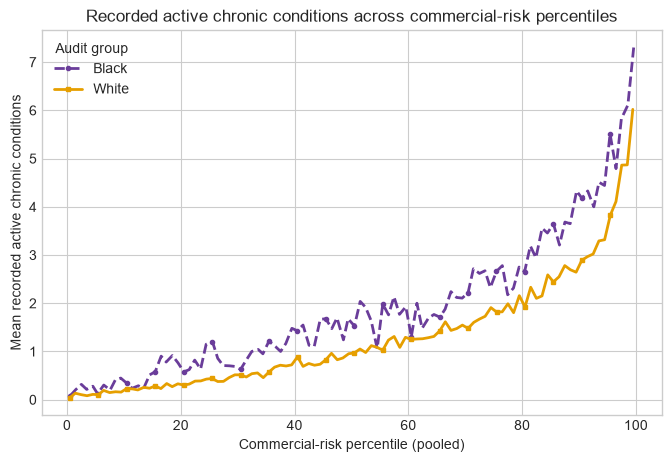

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))

for race, style in RACE_STYLES.items():
    plot_data = illness_by_risk.loc[illness_by_risk["race"] == race]
    ax.plot(
        plot_data["risk_percentile"],
        plot_data["mean_chronic_conditions"],
        label=race.title(),
        linewidth=2,
        markersize=3,
        markevery=5,
        **style,
    )

ax.set(
    xlabel="Commercial-risk percentile (pooled)",
    ylabel="Mean recorded active chronic conditions",
    title="Recorded active chronic conditions across commercial-risk percentiles",
)
ax.legend(title="Audit group")
plt.show()


**Read the figure:** Describe the vertical ordering of the two series,
especially at higher percentiles. Do not rely on color alone: the Black series
uses dashed lines and circles; the White series uses solid lines and squares.

**Your observation:** [Write one or two sentences here.]


## Task 3 — Describe the fixed top-3% capacity group

The program applies one pooled capacity rule to all patient-year rows; it does
not select 3% separately within each race. The target is
`ceil(0.03 × number of rows)`, so the procedure can select a whole number of
rows. If scores tie at the selection boundary, the original CSV row number
breaks the tie.

### 3A — Translate 3% capacity into a number of rows

Create two scalar variables:

- `selection_fraction`: the decimal value `0.03`, meaning 3% of all rows in
  the pooled `audit` DataFrame; and
- `number_selected`: the integer number of rows the program can accept. Compute
  it by multiplying `selection_fraction` by `len(audit)`, rounding upward, and
  converting the result to an integer.

Display `number_selected`. With 48,784 rows, it should equal 1,464. Later steps
will use this value to select exactly 1,464 rows.

**Hint:** `np.ceil()` rounds upward but returns a floating-point value; convert
its result to `int`.


In [11]:
selection_fraction = 0.03
number_selected = int(
    np.ceil(selection_fraction * len(audit))
)
number_selected


1464

### 3B — Rank rows for the commercial decision

Create `commercial_ranking` from `risk_score_t` and the original row number.
Order higher scores first; within a tied score, order the smaller source-row
number first.

The template creates the two ranking columns. Replace the two `...` placeholders
with the appropriate sort directions (`True` or `False`).


In [12]:
commercial_ranking = audit[["risk_score_t"]].copy()
commercial_ranking["source_row"] = commercial_ranking.index
commercial_ranking = commercial_ranking.sort_values(
    ["risk_score_t", "source_row"],
    ascending=[False, True],
)
commercial_ranking.head()


,risk_score_t,source_row
10793,100.000000,10793
34164,100.000000,34164
10750,96.381858,10750
46511,95.583489,46511
16961,93.664005,16961


### 3C — Mark exactly the selected rows

Take the first `number_selected` row indices from `commercial_ranking`. Create
`commercial_selected` as `False` for every row, then change it to `True` only
for those selected indices.

Replace the two `...` placeholders, then confirm that the number of `True`
values equals `number_selected`.


In [13]:
selected_index = commercial_ranking.head(number_selected).index

audit["commercial_selected"] = False
audit.loc[selected_index, "commercial_selected"] = True

audit["commercial_selected"].sum()


np.int64(1464)

### 3D — Calculate one summary row for each race

Create `selected`, a DataFrame containing only rows where
`commercial_selected` is `True`. Then create an empty list named
`top_3_rows`.

For each race, use Boolean conditions to create:

- `race_rows`: every row in `audit` for that race; and
- `selected_race_rows`: every row in `selected` for that race.

Append one dictionary to `top_3_rows` for each race. Each dictionary should
contain:

- `race`: the race label;
- `selected_rows`: the number of rows in `selected_race_rows`;
- `fraction_of_selected`: that count divided by `len(selected)`;
- `within_race_selection_rate`: that count divided by `len(race_rows)`; and
- `mean_chronic_conditions`: mean `gagne_sum_t` in `selected_race_rows`.

The template supplies the loop and row filtering. Replace the four `...`
placeholders with the required calculations.


In [14]:
selected = audit.loc[audit["commercial_selected"]].copy()
top_3_rows = []

for race_name in ["black", "white"]:
    race_rows = audit.loc[audit["race"] == race_name]
    selected_race_rows = selected.loc[selected["race"] == race_name]

    top_3_rows.append(
        {
            "race": race_name,
            "selected_rows": len(selected_race_rows),
            "fraction_of_selected": len(selected_race_rows) / len(selected),
            "within_race_selection_rate": (
                len(selected_race_rows) / len(race_rows)
            ),
            "mean_chronic_conditions": (
                selected_race_rows["gagne_sum_t"].mean()
            ),
        }
    )


### 3E — Assemble `top_3_summary`

Convert `top_3_rows` into a pandas DataFrame named `top_3_summary`. Move its
`race` column into the index so the two data rows are labeled `black` and
`white`. Display the DataFrame rounded to four decimal places.


In [15]:
top_3_summary = pd.DataFrame(top_3_rows).set_index("race")
top_3_summary.round(4)


,selected_rows,fraction_of_selected,within_race_selection_rate,mean_chronic_conditions
race,,,,
black,293,0.2001,0.0525,6.6212
white,1171,0.7999,0.0271,5.2109


## END-OF-SECTION CHECKPOINT — worked answer

Black patient-year rows have higher mean recorded active chronic-condition
counts than White rows at many similar commercial-risk percentiles, with the
gap especially visible in the upper range. The paper describes this as a
difference in illness burden; here it is specifically a difference in the
recorded active-condition-count proxy.

The exact top 3% contains 1,464 rows. Of these, 293 (20.0%) are Black and 1,171
(80.0%) are White. About 5.25% of all Black rows are selected versus 2.71% of
all White rows. Selected Black rows average about 6.62 recorded active
conditions, compared with 5.21 for selected White rows.

The commercial score therefore does not rank the two groups equally on this
recorded health-status proxy. To be selected by the commercial algorithm, a Black patient needs to have more active chronic conditions than a White patient with the same commercial score on average.


## Alternative implementations

The worked tasks above favor explicit intermediate objects and elementary
loops for the group summaries. The same results can be obtained in other ways.

- The first alternative recreates Task 1 without pandas `rank()` or `qcut()`.
- The next two alternatives show the more compact pandas versions of the Task
  2 and Task 3 summary tables.

Separate object names are used so these examples do not replace the objects
created in the main solution.


### Alternative for Task 1 — Sorting and loops instead of `rank()` and `qcut()`

This version sorts the rows by score, walks through tied scores to calculate
their shared average percentile, and assigns the 100 bin numbers with ordinary
integer positions.


In [16]:
elementary_audit = df.loc[:, section_3_columns].copy()

ordered_rows = elementary_audit[["risk_score_t"]].copy()
ordered_rows["source_row"] = ordered_rows.index
ordered_rows = ordered_rows.sort_values(
    ["risk_score_t", "source_row"],
    ascending=[True, True],
)

row_order = ordered_rows.index.tolist()
score_order = ordered_rows["risk_score_t"].tolist()
number_of_rows = len(row_order)

percentile_for_row = {}
start = 0

while start < number_of_rows:
    stop = start

    while (
        stop + 1 < number_of_rows
        and score_order[stop + 1] == score_order[start]
    ):
        stop += 1

    first_rank = start + 1
    last_rank = stop + 1
    average_rank = (first_rank + last_rank) / 2
    percentile = (average_rank / number_of_rows) * 100

    for position in range(start, stop + 1):
        row_index = row_order[position]
        percentile_for_row[row_index] = percentile

    start = stop + 1

elementary_audit["risk_percentile"] = [
    percentile_for_row[row_index]
    for row_index in elementary_audit.index
]

bin_for_row = {}

for position, row_index in enumerate(row_order, start=1):
    bin_number = max(
        1,
        int(
            np.ceil(
                100 * (position - 1) / (number_of_rows - 1)
            )
        ),
    )
    bin_for_row[row_index] = bin_number

elementary_audit["risk_bin"] = [
    bin_for_row[row_index]
    for row_index in elementary_audit.index
]

pd.DataFrame(
    {
        "matches_rank_percentiles": [
            np.allclose(
                elementary_audit["risk_percentile"],
                audit["risk_percentile"],
            )
        ],
        "matches_qcut_bins": [
            elementary_audit["risk_bin"].equals(audit["risk_bin"])
        ],
    }
)


,matches_rank_percentiles,matches_qcut_bins
0,True,True


### Compact alternative for Task 2 — `groupby()` with `agg()`

Named aggregation can replace the nested loops from 2A. It is shorter, but it
performs the same grouping and computes the same five columns.


In [17]:
illness_by_risk_compact = (
    audit.groupby(["risk_bin", "race"], as_index=False)
    .agg(
        risk_percentile=("risk_percentile", "mean"),
        mean_chronic_conditions=("gagne_sum_t", "mean"),
        rows=("gagne_sum_t", "size"),
    )
    .sort_values(["race", "risk_percentile"])
)

illness_by_risk_compact.head()


,risk_bin,race,risk_percentile,mean_chronic_conditions,rows
0,1,black,0.553753,0.079365,63
2,2,black,1.519917,0.206349,63
4,3,black,2.528770,0.317460,63
6,4,black,3.456337,0.213115,61
8,5,black,4.544282,0.279412,68


### Compact alternative for Task 3 — grouped summary Series

`value_counts()` and `groupby()` can calculate the four race-specific summary
columns without an explicit loop.


In [18]:
selected_counts = selected["race"].value_counts()
all_counts = audit["race"].value_counts()
mean_conditions = selected.groupby("race")["gagne_sum_t"].mean()

top_3_summary_compact = pd.DataFrame(
    {
        "selected_rows": selected_counts,
        "fraction_of_selected": selected_counts / len(selected),
        "within_race_selection_rate": selected_counts / all_counts,
        "mean_chronic_conditions": mean_conditions,
    }
).sort_index()

top_3_summary_compact.round(4)


,selected_rows,fraction_of_selected,within_race_selection_rate,mean_chronic_conditions
race,,,,
black,293,0.2001,0.0525,6.6212
white,1171,0.7999,0.0271,5.2109
